# Extra Trees

### What you buy by picking the split point at random, and what it costs

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | The one line that separates an extremely randomised forest from an ordinary one, how to measure an ensemble's bias and variance instead of quoting the textbook claim about them, where the speed advantage comes from, how large it is and the dataset where it did not appear at all, and why the ranking between the two flips from dataset to dataset |
| **You should already know** | [Bagging](../01-bagging/) · [Random forests](../02-random-forest/) · [Decision trees](../../03-classification/06-decision-trees/) |
| **Datasets** | California Housing, UCI Bike Sharing, UCI Dry Bean, Breast Cancer Wisconsin |
| **Runtime** | Three to five minutes on a laptop CPU |
| **Next** | [04-04 AdaBoost](../04-adaboost/) |

---

## 1. The idea

A decision tree spends nearly all of its time answering one question at every
node: of all the ways I could cut this data, which cut is best? To answer it, the
tree sorts each candidate feature and scans every possible threshold, scoring
each one.

Extremely randomised trees, which everyone calls Extra Trees, refuse to do that
search. At each node, for each candidate feature, they **draw one threshold
uniformly at random** between that feature's smallest and largest value in the
node, and then pick the best of those few random offers. A feature might be split
in a place no sensible tree would ever choose.

That sounds like vandalism, and the claim made for it is that it helps. The
argument goes: a randomly placed cut makes each tree worse on its own, but it
makes the trees far less like each other, and an average of many weakly
correlated bad predictors can beat an average of many strongly correlated good
ones.

This chapter has one job, which is to check that claim with a measurement rather
than repeat it. Along the way there is a second difference between the two
methods that gets much less attention than it should, and it is not the split
rule.

In [1]:
import sys
import pathlib
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

X_cal, y_cal = datasets.california_housing()
print(f"California Housing: {X_cal.shape[0]:,} districts, {X_cal.shape[1]} columns")
print(f"target is median house value in hundreds of thousands of dollars, "
      f"capped at {y_cal.max():.1f}")

California Housing: 20,640 districts, 8 columns
target is median house value in hundreds of thousands of dollars, capped at 5.0


The mechanism first, on one node of one dataset. Take a sample of districts, look
at one feature, and plot the total squared error left over after splitting at
every possible threshold. A greedy tree walks that curve and stops at the bottom.
An extremely randomised tree throws a dart at the x-axis.

In [2]:
rng = np.random.default_rng(SEED)
sample = rng.choice(len(X_cal), 1500, replace=False)
X_node = X_cal.values[sample]
y_node = y_cal.values[sample]
FEATURES = list(X_cal.columns)


def split_curve(column, target):
    """Total squared error after splitting `column` at every midpoint between values.

    Written with cumulative sums rather than a Python loop, because this is the
    inner loop of tree building and its cost is the whole point of the chapter.
    """
    order = np.argsort(column, kind="stable")
    xs, ys = column[order], target[order]
    n = len(ys)

    left_n = np.arange(1, n)
    left_sum, left_square = np.cumsum(ys)[:-1], np.cumsum(ys ** 2)[:-1]
    right_n = n - left_n
    right_sum, right_square = ys.sum() - left_sum, (ys ** 2).sum() - left_square

    error = (left_square - left_sum ** 2 / left_n) + (right_square - right_sum ** 2 / right_n)
    thresholds = (xs[:-1] + xs[1:]) / 2
    distinct = xs[:-1] < xs[1:]                 # a threshold between equal values splits nothing
    return thresholds[distinct], error[distinct]


focus = FEATURES.index("MedInc")
thresholds, errors = split_curve(X_node[:, focus], y_node)
greedy_threshold = thresholds[np.argmin(errors)]

darts = rng.uniform(X_node[:, focus].min(), X_node[:, focus].max(), 12)
print(f"candidate thresholds the greedy search scored on this node: {len(thresholds):,}")
print(f"greedy tree picks MedInc <= {greedy_threshold:.3f}")
print(f"twelve random darts landed between {darts.min():.3f} and {darts.max():.3f}")

candidate thresholds the greedy search scored on this node: 1,382
greedy tree picks MedInc <= 5.032
twelve random darts landed between 2.481 and 12.766


In [3]:
def split_error(column, target, threshold):
    left = column <= threshold
    if left.all() or not left.any():
        return np.inf
    return sum(((target[side] - target[side].mean()) ** 2).sum() for side in (left, ~left))


TRIALS = 300

# Every feature is offered to both rules, so the only thing that differs is how a
# threshold is chosen once a feature is on the table. The greedy answer is computed
# once, because repeating it 300 times would produce the same number 300 times.
greedy_scores = []
for j in range(X_node.shape[1]):
    _, errs = split_curve(X_node[:, j], y_node)
    greedy_scores.append(errs.min() if len(errs) else np.inf)
greedy_choice = int(np.argmin(greedy_scores))

dart_choices = []
for trial in range(TRIALS):
    local = np.random.default_rng(1000 + trial)
    scores = [split_error(X_node[:, j], y_node,
                          local.uniform(X_node[:, j].min(), X_node[:, j].max()))
              for j in range(X_node.shape[1])]
    dart_choices.append(int(np.argmin(scores)))

chosen_feature = {"greedy (random forest)": [greedy_choice] * TRIALS,
                  "one random dart per feature (extra trees)": dart_choices}

for name, picks in chosen_feature.items():
    counts = pd.Series(picks).value_counts()
    print(f"{name}: {len(counts)} distinct feature(s) ever chosen across {TRIALS} draws, "
          f"most common {FEATURES[counts.index[0]]} ({counts.iloc[0] / TRIALS:.2f})")

greedy (random forest): 1 distinct feature(s) ever chosen across 300 draws, most common MedInc (1.00)
one random dart per feature (extra trees): 6 distinct feature(s) ever chosen across 300 draws, most common MedInc (0.81)


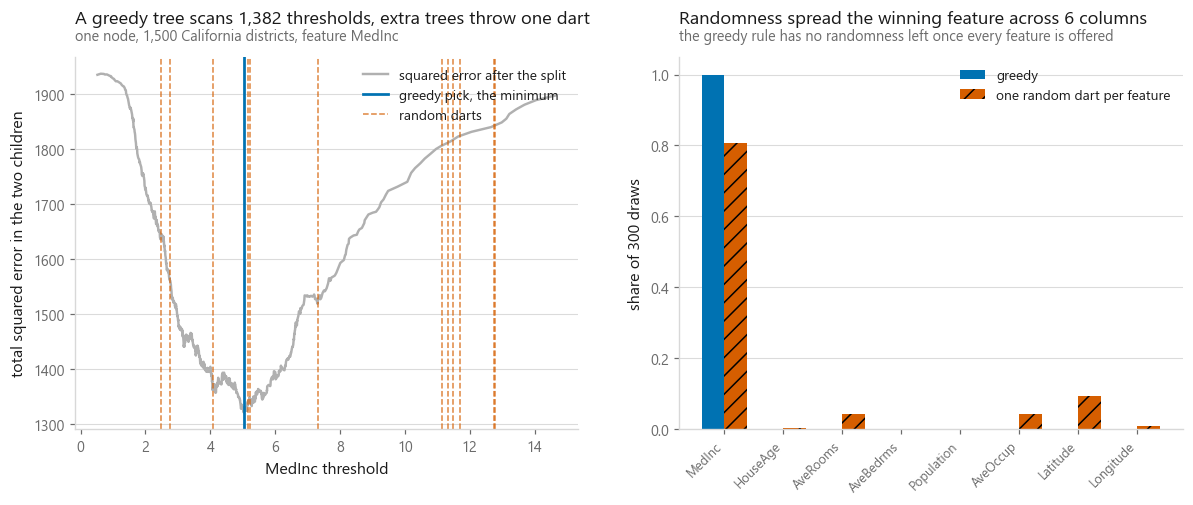

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.4))

axes[0].plot(thresholds, errors, color=style.NEUTRAL, lw=1.6, label="squared error after the split")
axes[0].axvline(greedy_threshold, color=style.PALETTE[0], lw=1.8,
                label="greedy pick, the minimum")
for i, dart in enumerate(darts):
    axes[0].axvline(dart, color=style.HIGHLIGHT, lw=1.0, ls="--", alpha=0.75,
                    label="random darts" if i == 0 else None)
axes[0].set_xlabel("MedInc threshold")
axes[0].set_ylabel("total squared error in the two children")
axes[0].legend(loc="upper right", fontsize=9)
style.title(axes[0], f"A greedy tree scans {len(thresholds):,} thresholds, extra trees throw one dart",
            f"one node, {len(y_node):,} California districts, feature MedInc")

positions = np.arange(len(FEATURES))
width = 0.38
for i, (name, picks) in enumerate(chosen_feature.items()):
    counts = np.bincount(picks, minlength=len(FEATURES)) / TRIALS
    axes[1].bar(positions + (i - 0.5) * width, counts, width=width,
                color=[style.PALETTE[0], style.HIGHLIGHT][i], hatch=["", "//"][i],
                label=name.split(" (")[0])
axes[1].set_xticks(positions, FEATURES, rotation=45, ha="right", fontsize=8.5)
axes[1].set_ylabel(f"share of {TRIALS} draws")
axes[1].set_ylim(0, 1.05)
axes[1].legend(loc="upper right", fontsize=9)
spread = len(set(chosen_feature["one random dart per feature (extra trees)"]))
style.title(axes[1], f"Randomness spread the winning feature across {spread} columns",
            "the greedy rule has no randomness left once every feature is offered")

style.save(fig, FIG / "fig-01-split-choice.png")

The left panel is the mechanism and the right panel is its consequence. Offered
every feature, the greedy rule is deterministic: same data, same answer, every
time. Once the threshold is a coin toss, the winning feature stops being fixed,
and two trees grown on the same rows start to disagree from the root down.

In a real random forest the greedy rule does get some randomness back, from the
bootstrap sample and from `max_features`. The point of forcing both to see all
eight columns here is to isolate what the threshold rule alone contributes.

## 2. The maths, and where the time goes

### Why decorrelation matters

The variance of an average of $B$ predictors with variance $\sigma^2$ and pairwise
correlation $\rho$, from the [random forest chapter](../02-random-forest/):

$$\operatorname{Var}(\bar{f}) = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$$

Adding trees kills the second term and leaves the first untouched. The floor is
$\rho\sigma^2$, so the only way to lower the floor is to lower $\rho$ or lower
$\sigma^2$.

Extra Trees trade one against the other. Random thresholds push $\rho$ down, and
they push each individual tree's error up. Whether the product falls is an
empirical question about your data, which is why section 5 measures it rather
than assuming it.

### Where the speed comes from, and when it reaches the clock

For a node with $n$ rows and $m$ candidate features, the greedy rule sorts each
feature and scans it: $O(m \cdot n \log n)$. The random rule reads a minimum and a
maximum and evaluates one threshold: $O(m \cdot n)$ with no sort at all.

The sort is the expensive part, and it is not a small constant. But it is a
saving per split, not a saving per fit, so how much of it reaches the clock
depends on how much of the fit is split search. Section 4 measures that across
four datasets of very different sizes, and section 5 times the same pair again
under different settings and does not fully agree.

### The difference nobody mentions

scikit-learn's defaults for the two classes do not differ only in the split rule.

In [5]:
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                              RandomForestClassifier, ExtraTreesClassifier)

defaults = pd.DataFrame([
    {"class": name,
     "bootstrap": estimator.bootstrap,
     "max_features": estimator.max_features}
    for name, estimator in [("RandomForestRegressor", RandomForestRegressor()),
                            ("ExtraTreesRegressor", ExtraTreesRegressor()),
                            ("RandomForestClassifier", RandomForestClassifier()),
                            ("ExtraTreesClassifier", ExtraTreesClassifier())]
])
print(defaults.to_string(index=False))
print(f"\nmax_features matches within each task type: "
      f"{defaults.max_features.iloc[0] == defaults.max_features.iloc[1]} for regressors, "
      f"{defaults.max_features.iloc[2] == defaults.max_features.iloc[3]} for classifiers")
print(f"bootstrap matches: {defaults.bootstrap.iloc[0] == defaults.bootstrap.iloc[1]}")

                 class  bootstrap max_features
 RandomForestRegressor       True          1.0
   ExtraTreesRegressor      False          1.0
RandomForestClassifier       True         sqrt
  ExtraTreesClassifier      False         sqrt

max_features matches within each task type: True for regressors, True for classifiers
bootstrap matches: False


A random forest resamples the rows for every tree. Extra Trees, by default, do
not: every tree sees the whole training set and gets its diversity entirely from
the random thresholds. Comparing the two classes out of the box therefore moves
two things at once, and any honest measurement has to hold `bootstrap` fixed.

Section 4 holds it fixed, and it holds it **on** rather than off, for a reason
that is worth its own measurement.

## 3. From scratch

One tree, written so the splitter is an argument. Swapping `greedy_split` for
`dart_split` is the entire difference between the two methods, and having them
side by side in the same function makes that concrete.

In [6]:
def greedy_split(X, y, features, rng):
    """Scan every threshold on every offered feature and return the best."""
    best = None
    for j in features:
        thresholds, errors = split_curve(X[:, j], y)
        if not len(thresholds):
            continue
        k = int(np.argmin(errors))
        if best is None or errors[k] < best[2]:
            best = (j, float(thresholds[k]), float(errors[k]))
    return best


def dart_split(X, y, features, rng):
    """Draw one uniform threshold per offered feature and keep the best of those."""
    best = None
    for j in features:
        low, high = X[:, j].min(), X[:, j].max()
        if high <= low:
            continue
        threshold = float(rng.uniform(low, high))
        error = split_error(X[:, j], y, threshold)
        if best is None or error < best[2]:
            best = (j, threshold, error)
    return best


class SimpleTree:
    """A regression tree that takes its split rule as a parameter."""

    def __init__(self, splitter, max_depth=6, min_samples=20, max_features=None, seed=0):
        self.splitter = splitter
        self.max_depth = max_depth
        self.min_samples = min_samples
        self.max_features = max_features
        self.seed = seed

    def fit(self, X, y):
        self.n_features_ = X.shape[1]
        self.root_ = self._grow(np.asarray(X, float), np.asarray(y, float), 0,
                                np.random.default_rng(self.seed))
        return self

    def _grow(self, X, y, depth, rng):
        if depth >= self.max_depth or len(y) < self.min_samples or y.std() == 0:
            return {"leaf": True, "value": float(y.mean())}

        k = self.max_features or self.n_features_
        features = rng.choice(self.n_features_, min(k, self.n_features_), replace=False)
        found = self.splitter(X, y, features, rng)
        if found is None:
            return {"leaf": True, "value": float(y.mean())}

        feature, threshold, _ = found
        left = X[:, feature] <= threshold
        if left.all() or not left.any():
            return {"leaf": True, "value": float(y.mean())}

        return {"leaf": False, "feature": feature, "threshold": threshold,
                "left": self._grow(X[left], y[left], depth + 1, rng),
                "right": self._grow(X[~left], y[~left], depth + 1, rng)}

    def predict(self, X):
        X = np.asarray(X, float)
        out = np.empty(len(X))
        self._fill(self.root_, X, out, np.arange(len(X)))
        return out

    def _fill(self, node, X, out, rows):
        """Walk the tree once per node rather than once per row."""
        if len(rows) == 0:
            return
        if node["leaf"]:
            out[rows] = node["value"]
            return
        left = X[rows, node["feature"]] <= node["threshold"]
        self._fill(node["left"], X, out, rows[left])
        self._fill(node["right"], X, out, rows[~left])

In [7]:
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

X_small, X_hold, y_small, y_hold = train_test_split(
    X_cal.values, y_cal.values, train_size=1200, test_size=3000, random_state=SEED)

N_TREES = 15
scratch = {}
for name, splitter in [("greedy", greedy_split), ("random darts", dart_split)]:
    started = time.perf_counter()
    forest = [SimpleTree(splitter, max_depth=8, max_features=4, seed=SEED + i).fit(X_small, y_small)
              for i in range(N_TREES)]
    build_seconds = time.perf_counter() - started

    per_tree = np.array([r2_score(y_hold, tree.predict(X_hold)) for tree in forest])
    ensemble = np.mean([tree.predict(X_hold) for tree in forest], axis=0)
    scratch[name] = {
        "seconds to build": build_seconds,
        "mean single tree R2": per_tree.mean(),
        "worst single tree R2": per_tree.min(),
        f"{N_TREES} trees averaged R2": r2_score(y_hold, ensemble),
    }

scratch = pd.DataFrame(scratch).T
print(f"{N_TREES} trees each, {len(y_small):,} training rows, depth 8, 4 features offered per node")
print(scratch.round(4).to_string())

lift = scratch[f"{N_TREES} trees averaged R2"] - scratch["mean single tree R2"]
print(f"\ngain from averaging, greedy       : {lift['greedy']:+.4f}")
print(f"gain from averaging, random darts : {lift['random darts']:+.4f}")

15 trees each, 1,200 training rows, depth 8, 4 features offered per node
              seconds to build  mean single tree R2  worst single tree R2  15 trees averaged R2
greedy                  0.2141               0.5399                0.5006                0.6800
random darts            0.1228               0.4489                0.3111                0.5975

gain from averaging, greedy       : +0.1401
gain from averaging, random darts : +0.1485


Two numbers to read against each other. The single-tree column is where the cost
of random splitting shows up, and the gain-from-averaging line is where the
benefit shows up. If the claim in section 1 holds, the random version starts
further behind and climbs further.

This implementation is deliberately naive, so the timing above measures my Python
rather than the algorithm. scikit-learn's version is Cython and the constant
factors are completely different. Section 4 times the real thing.

## 4. In practice

First, the two changes separated. Same number of trees, same seed, same data,
with `bootstrap` moved on its own and the split rule moved on its own.

In [8]:
X_tr, X_te, y_tr, y_te = train_test_split(X_cal.values, y_cal.values,
                                          test_size=0.25, random_state=SEED)

variants = {
    "random forest, bootstrap on (default)": RandomForestRegressor(
        n_estimators=200, random_state=SEED, n_jobs=-1),
    "random forest, bootstrap off": RandomForestRegressor(
        n_estimators=200, bootstrap=False, random_state=SEED, n_jobs=-1),
    "extra trees, bootstrap off (default)": ExtraTreesRegressor(
        n_estimators=200, random_state=SEED, n_jobs=-1),
    "extra trees, bootstrap on": ExtraTreesRegressor(
        n_estimators=200, bootstrap=True, random_state=SEED, n_jobs=-1),
}

def tree_spread(model, X, n_trees=15):
    """How far apart the individual trees inside one fitted ensemble are.

    Zero means every tree is a copy of every other tree, in which case the
    ensemble is one tree wearing a costume.
    """
    stack = np.array([tree.predict(X) for tree in model.estimators_[:n_trees]])
    return float(stack.std(axis=0).mean())


isolation = []
for name, estimator in variants.items():
    started = time.perf_counter()
    estimator.fit(X_tr, y_tr)
    isolation.append({"variant": name,
                      "R2 on held out": estimator.score(X_te, y_te),
                      "spread between trees": tree_spread(estimator, X_te[:2000]),
                      "fit seconds": time.perf_counter() - started})

isolation = pd.DataFrame(isolation)
print(isolation.round(4).to_string(index=False))

score = isolation["R2 on held out"]
print(f"\nsplit rule alone, both with bootstrap on   : {score[3] - score[0]:+.4f} R2")
print(f"bootstrap alone, both with random splits   : {score[3] - score[2]:+.4f} R2")
print(f"bootstrap alone, both with greedy splits   : {score[0] - score[1]:+.4f} R2")
print(f"the two library defaults against each other: {score[2] - score[0]:+.4f} R2")

collapsed = isolation.loc[1, "spread between trees"]
print(f"\nspread between the trees of a greedy forest with bootstrap off: {collapsed:.6f}")
print(f"the same for extra trees with bootstrap off: "
      f"{isolation.loc[2, 'spread between trees']:.6f}")

                              variant  R2 on held out  spread between trees  fit seconds
random forest, bootstrap on (default)          0.7947                0.4520       3.8023
         random forest, bootstrap off          0.6139                0.0921       5.9497
 extra trees, bootstrap off (default)          0.8083                0.4829       1.8282
            extra trees, bootstrap on          0.7996                0.5069       1.3993

split rule alone, both with bootstrap on   : +0.0049 R2
bootstrap alone, both with random splits   : -0.0087 R2
bootstrap alone, both with greedy splits   : +0.1808 R2
the two library defaults against each other: +0.0136 R2

spread between the trees of a greedy forest with bootstrap off: 0.092098
the same for extra trees with bootstrap off: 0.482859


The `spread between trees` column is the one to stop at, and it is the reason
section 2 promised this measurement.

A greedy tree with all features offered and no bootstrap is **deterministic**.
Same rows in, same tree out. So `RandomForestRegressor(bootstrap=False)` with the
default `max_features=1.0` does not build a forest at all: it builds the same tree
two hundred times and averages it with itself. The printed spread says how close
to literally that it gets.

Extra Trees have no such problem, because the random thresholds are their source
of diversity and they do not need the bootstrap for it. That asymmetry is exactly
why the two classes ship with different defaults, and it decides how the rest of
this notebook is set up: **bootstrap stays on for both**, since turning it off
would hand Extra Trees a win by disabling its opponent.

With that settled, the two lines above are the honest split of the defaults.
Whichever of them is larger is the change that a naive `ExtraTreesRegressor()`
against `RandomForestRegressor()` comparison is mostly measuring.

### Training time, which is the one advantage that always holds

Timed single-threaded on purpose. `n_jobs=-1` measures how many cores you have as
much as it measures the algorithm, and the question here is how much work each
method does.

In [9]:
from sklearn.preprocessing import LabelEncoder

X_bike, y_bike = datasets.bike_sharing()
X_bean, y_bean = datasets.dry_bean()
X_bc, y_bc = datasets.breast_cancer()

TASKS = {
    "California Housing": (X_cal.values, y_cal.values, "regression"),
    "Bike Sharing": (X_bike.values, y_bike.values, "regression"),
    "Dry Bean": (X_bean.values, LabelEncoder().fit_transform(y_bean), "classification"),
    "Breast Cancer": (X_bc.values, y_bc.values, "classification"),
}


def build(kind, family, n_estimators, jobs=1, bootstrap=True):
    """One estimator constructor for both task types, with bootstrap held fixed on."""
    options = dict(n_estimators=n_estimators, bootstrap=bootstrap,
                   random_state=SEED, n_jobs=jobs)
    if kind == "regression":
        return (RandomForestRegressor(**options) if family == "random forest"
                else ExtraTreesRegressor(**options))
    return (RandomForestClassifier(**options) if family == "random forest"
            else ExtraTreesClassifier(**options))


TIMED_TREES = 30              # small on purpose: cost is linear in trees, and this runs single-threaded
timing = []
for dataset, (Xd, yd, kind) in TASKS.items():
    for family in ["random forest", "extra trees"]:
        model = build(kind, family, TIMED_TREES, jobs=1)
        started = time.perf_counter()
        model.fit(Xd, yd)
        timing.append({"dataset": dataset, "family": family, "rows": len(yd),
                       "columns": Xd.shape[1],
                       "fit seconds": time.perf_counter() - started})

timing = pd.DataFrame(timing)
wide = timing.pivot(index="dataset", columns="family", values="fit seconds")
wide["speedup"] = wide["random forest"] / wide["extra trees"]
# Size, because the saving is per split and only shows up when split search is
# what you are paying for.
wide["rows"] = timing.groupby("dataset")["rows"].first()
wide["columns"] = timing.groupby("dataset")["columns"].first()
print(f"one fit of {TIMED_TREES} trees, single-threaded, bootstrap on for both")
print(wide.round(3).to_string())
print(f"\nsmallest speedup {wide['speedup'].min():.2f}x on {wide['speedup'].idxmin()} "
      f"({wide.loc[wide['speedup'].idxmin(), 'rows']:,} rows), "
      f"largest {wide['speedup'].max():.2f}x on {wide['speedup'].idxmax()} "
      f"({wide.loc[wide['speedup'].idxmax(), 'rows']:,} rows)")

one fit of 30 trees, single-threaded, bootstrap on for both
family              extra trees  random forest  speedup   rows  columns
dataset                                                                
Bike Sharing              0.887          1.538    1.734  17379       12
Breast Cancer             0.031          0.059    1.906    569       30
California Housing        1.015          3.669    3.614  20640        8
Dry Bean                  0.214          1.206    5.643  13611       16

smallest speedup 1.73x on Bike Sharing (17,379 rows), largest 5.64x on Dry Bean (13,611 rows)


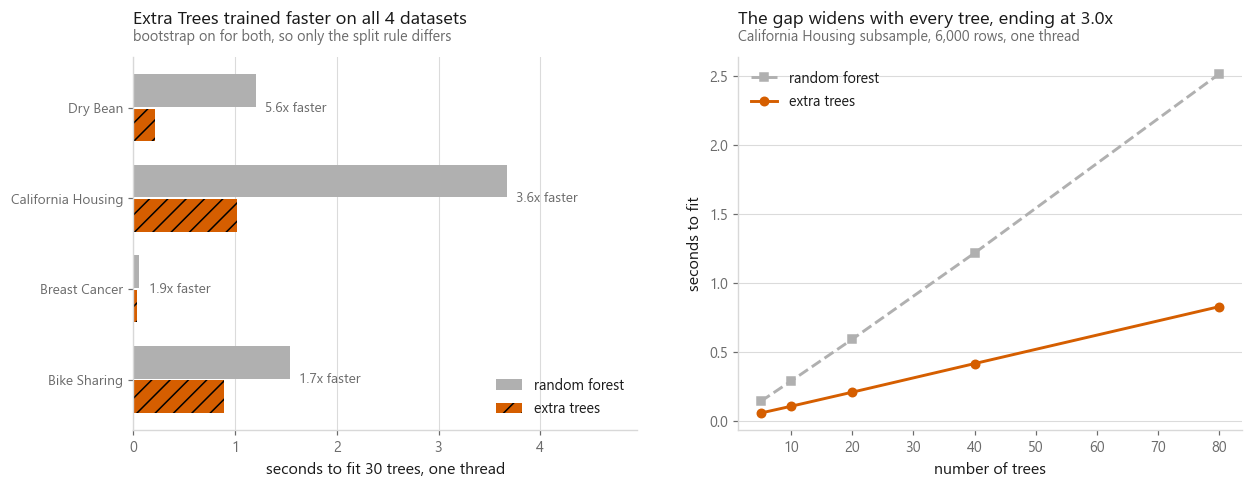

In [10]:
TREE_COUNTS = [5, 10, 20, 40, 80]
time_curve = {"random forest": [], "extra trees": []}
sub = np.random.default_rng(SEED).choice(len(X_cal), 6000, replace=False)
X_sub, y_sub = X_cal.values[sub], y_cal.values[sub]

for family in time_curve:
    for count in TREE_COUNTS:
        model = build("regression", family, count, jobs=1)
        started = time.perf_counter()
        model.fit(X_sub, y_sub)
        time_curve[family].append(time.perf_counter() - started)

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.4))

order = wide.sort_values("speedup").index
positions = np.arange(len(order))
for i, family in enumerate(["random forest", "extra trees"]):
    axes[0].barh(positions + (0.19 if i == 0 else -0.19), wide.loc[order, family],
                 height=0.36, color=[style.NEUTRAL, style.HIGHLIGHT][i],
                 hatch=["", "//"][i], label=family)
for i, dataset in enumerate(order):
    axes[0].annotate(f"{wide.loc[dataset, 'speedup']:.1f}x faster",
                     xy=(wide.loc[dataset, "random forest"], i), xytext=(6, 0),
                     textcoords="offset points", va="center", fontsize=9, color=style.MUTED)
axes[0].set_yticks(positions, order, fontsize=9)
axes[0].set_xlim(0, wide["random forest"].max() * 1.35)
axes[0].set_xlabel(f"seconds to fit {TIMED_TREES} trees, one thread")
axes[0].grid(axis="y", visible=False)
axes[0].grid(axis="x", visible=True)
axes[0].legend(loc="lower right")
style.title(axes[0], f"Extra Trees trained faster on all {len(order)} datasets"
            if (wide["speedup"] > 1).all() else "Extra Trees did not win every timing",
            "bootstrap on for both, so only the split rule differs")

for family, colour, marker, dash in [("random forest", style.NEUTRAL, style.MARKERS[1], "--"),
                                     ("extra trees", style.HIGHLIGHT, style.MARKERS[0], "-")]:
    axes[1].plot(TREE_COUNTS, time_curve[family], color=colour, marker=marker,
                 ls=dash, label=family)
axes[1].set_xlabel("number of trees")
axes[1].set_ylabel("seconds to fit")
axes[1].legend(loc="upper left")
slope_ratio = (time_curve["random forest"][-1] / time_curve["extra trees"][-1])
style.title(axes[1], f"The gap widens with every tree, ending at {slope_ratio:.1f}x",
            f"California Housing subsample, {len(y_sub):,} rows, one thread")

style.save(fig, FIG / "fig-02-training-time.png")

Both curves are straight lines through the origin, because trees are built
independently and cost is linear in their number. What differs is the slope, and
the slope is the per-tree cost the sort creates.

The ratio is not constant across datasets, and the printed table says which one
gains most. The sort is $O(n \log n)$ per feature per node, so the advantage
should grow with rows and with the number of distinct values a column takes.

### Does more randomness need more trees?

Less correlated trees should mean the average converges more slowly at first and
to a different floor. That predicts two curves with different shapes rather than
one shifted copy of the other.


California Housing (R squared)
     random forest  extra trees  extra trees minus random forest
1           0.5264       0.4953                          -0.0311
3           0.6631       0.6555                          -0.0075
5           0.6905       0.6890                          -0.0015
10          0.7110       0.7044                          -0.0066
25          0.7308       0.7239                          -0.0069
50          0.7363       0.7280                          -0.0083
100         0.7401       0.7332                          -0.0068
200         0.7410       0.7357                          -0.0053

Dry Bean (accuracy)
     random forest  extra trees  extra trees minus random forest
1           0.8933       0.8722                          -0.0212
3           0.9107       0.8998                          -0.0109
5           0.9157       0.9068                          -0.0088
10          0.9186       0.9130                          -0.0056
25          0.9183       0.9195      

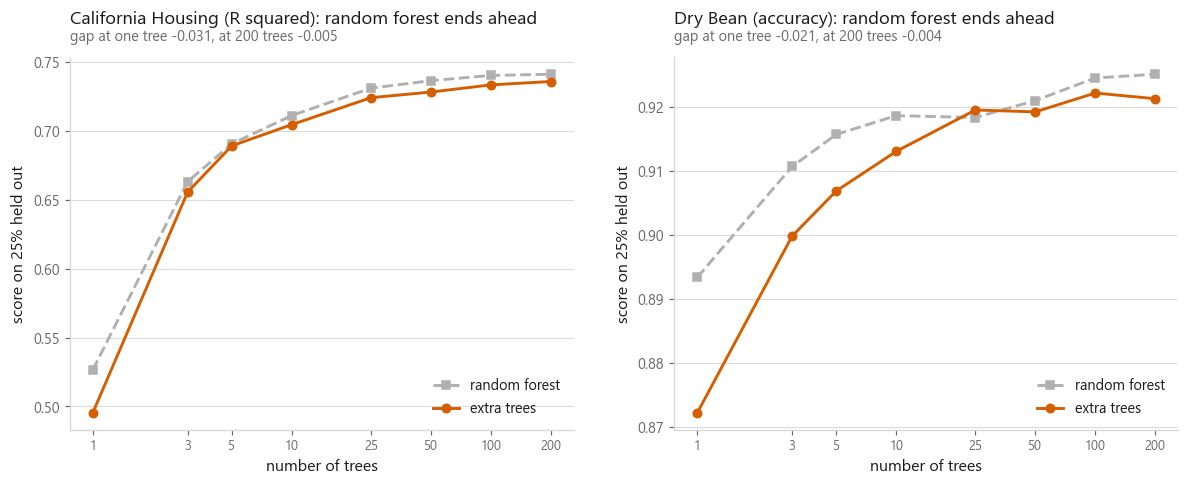

In [11]:
SWEEP = [1, 3, 5, 10, 25, 50, 100, 200]
sweep_sets = {
    "California Housing (R squared)": (X_sub, y_sub, "regression"),
    "Dry Bean (accuracy)": (X_bean.values, LabelEncoder().fit_transform(y_bean), "classification"),
}

sweeps = {}
for dataset, (Xd, yd, kind) in sweep_sets.items():
    Xa, Xb, ya, yb = train_test_split(Xd, yd, test_size=0.25, random_state=SEED,
                                      stratify=yd if kind == "classification" else None)
    sweeps[dataset] = {}
    for family in ["random forest", "extra trees"]:
        sweeps[dataset][family] = [
            build(kind, family, count, jobs=-1).fit(Xa, ya).score(Xb, yb) for count in SWEEP]

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.4))
for ax, (dataset, curves) in zip(axes, sweeps.items()):
    for family, colour, marker, dash in [("random forest", style.NEUTRAL, style.MARKERS[1], "--"),
                                         ("extra trees", style.HIGHLIGHT, style.MARKERS[0], "-")]:
        ax.plot(SWEEP, curves[family], color=colour, marker=marker, ls=dash, label=family)
    ax.set_xscale("log")
    ax.set_xticks(SWEEP, [str(s) for s in SWEEP], fontsize=8.5)
    ax.minorticks_off()
    ax.set_xlabel("number of trees")
    ax.set_ylabel("score on 25% held out")
    ax.legend(loc="lower right")
    winner = max(curves, key=lambda f: curves[f][-1])
    style.title(ax, f"{dataset}: {winner} ends ahead",
                f"gap at one tree {curves['extra trees'][0] - curves['random forest'][0]:+.3f}, "
                f"at {SWEEP[-1]} trees {curves['extra trees'][-1] - curves['random forest'][-1]:+.3f}")

style.save(fig, FIG / "fig-03-tree-count.png")

for dataset, curves in sweeps.items():
    frame = pd.DataFrame(curves, index=SWEEP)
    frame["extra trees minus random forest"] = frame["extra trees"] - frame["random forest"]
    print(f"\n{dataset}")
    print(frame.round(4).to_string())

The single-tree column is the clearest statement of the trade in the whole
notebook. One extremely randomised tree against one greedy tree, on the same data,
is the cost of random splitting with none of the benefit collected yet. Whatever
the gap is there, the question is how much of it the averaging gives back.

## 5. When it wins, when it loses

### Bias and variance, measured rather than asserted

The claim is that random splits raise bias and lower variance. Both are
properties of a *procedure* across datasets, not of one fitted model, so measuring
them needs repetition: draw a fresh training set, fit, predict a fixed test set,
and do it many times.

For squared error the decomposition is

$$\mathbb{E}\big[(y - \hat{f}(x))^2\big]
  = \underbrace{\sigma^2_{\text{noise}}}_{\text{irreducible}}
  + \underbrace{\big(\mathbb{E}[\hat{f}(x)] - f(x)\big)^2}_{\text{bias}^2}
  + \underbrace{\operatorname{Var}\big(\hat{f}(x)\big)}_{\text{variance}}$$

One honest caveat before the numbers. With a single observed $y$ per test point
there is no way to separate the noise term from the bias term, so what I plot as
bias below is **bias squared plus noise**. That is fine for this comparison,
because the noise term is a property of the data and is identical for both
methods, so any difference between the two bias bars is real bias.

In [12]:
REPEATS = 30
SAMPLE = 2500

pool, X_fixed, pool_y, y_fixed = train_test_split(
    X_cal.values, y_cal.values, test_size=3000, random_state=SEED)

configurations = [("random forest", 1), ("extra trees", 1),
                  ("random forest", 60), ("extra trees", 60)]

decomposition = []
for family, count in configurations:
    picker = np.random.default_rng(SEED)
    predictions = np.empty((REPEATS, len(y_fixed)))
    for repeat in range(REPEATS):
        rows = picker.choice(len(pool), SAMPLE, replace=False)
        model = build("regression", family, count, jobs=-1)
        predictions[repeat] = model.fit(pool[rows], pool_y[rows]).predict(X_fixed)

    average = predictions.mean(axis=0)
    bias_plus_noise = float(np.mean((average - y_fixed) ** 2))
    variance = float(np.mean(predictions.var(axis=0)))
    decomposition.append({
        "family": family, "trees": count,
        "bias2 + noise": bias_plus_noise,
        "variance": variance,
        "expected error": float(np.mean((predictions - y_fixed) ** 2)),
    })

decomposition = pd.DataFrame(decomposition)
decomposition["sum of parts"] = decomposition["bias2 + noise"] + decomposition["variance"]
print(f"{REPEATS} training sets of {SAMPLE:,} rows each, "
      f"one fixed test set of {len(y_fixed):,} rows")
print(decomposition.round(4).to_string(index=False))

for count in [1, 60]:
    block = decomposition[decomposition["trees"] == count].set_index("family")
    bias_gap = block.loc["extra trees", "bias2 + noise"] - block.loc["random forest", "bias2 + noise"]
    var_gap = block.loc["extra trees", "variance"] - block.loc["random forest", "variance"]
    print(f"\nat {count} tree(s): extra trees carry {bias_gap:+.4f} bias and "
          f"{var_gap:+.4f} variance against the forest")
    print(f"  textbook prediction is higher bias and lower variance: "
          f"{bias_gap > 0 and var_gap < 0}")

30 training sets of 2,500 rows each, one fixed test set of 3,000 rows
       family  trees  bias2 + noise  variance  expected error  sum of parts
random forest      1         0.3264    0.4147          0.7411        0.7411
  extra trees      1         0.3132    0.4618          0.7750        0.7750
random forest     60         0.3159    0.0354          0.3513        0.3513
  extra trees     60         0.3212    0.0233          0.3445        0.3445

at 1 tree(s): extra trees carry -0.0132 bias and +0.0471 variance against the forest
  textbook prediction is higher bias and lower variance: False

at 60 tree(s): extra trees carry +0.0053 bias and -0.0121 variance against the forest
  textbook prediction is higher bias and lower variance: True


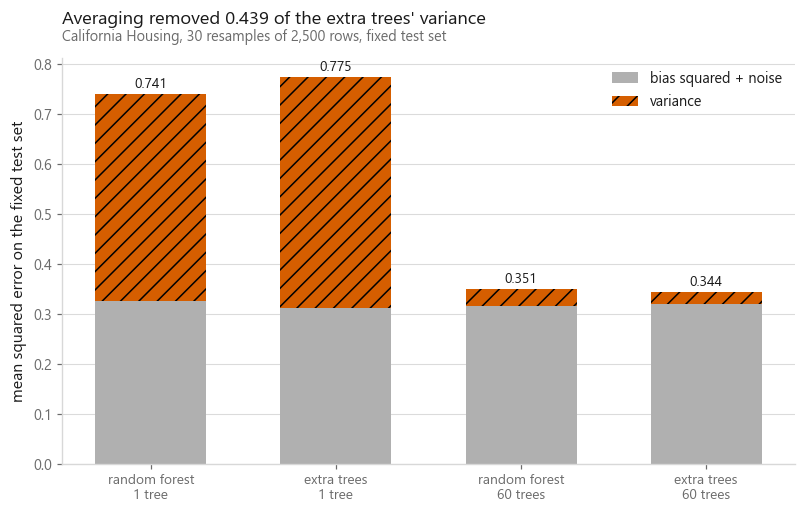

In [13]:
fig, ax = plt.subplots(figsize=(8.6, 4.8))
labels = [f"{family}\n{count} tree{'s' if count > 1 else ''}"
          for family, count in configurations]
positions = np.arange(len(labels))

bias_values = decomposition["bias2 + noise"].to_numpy()
variance_values = decomposition["variance"].to_numpy()

ax.bar(positions, bias_values, width=0.6, color=style.NEUTRAL, label="bias squared + noise")
ax.bar(positions, variance_values, width=0.6, bottom=bias_values, color=style.HIGHLIGHT,
       hatch="//", label="variance")
for x, (bias, var) in enumerate(zip(bias_values, variance_values)):
    ax.annotate(f"{bias + var:.3f}", xy=(x, bias + var), xytext=(0, 4),
                textcoords="offset points", ha="center", fontsize=9, color=style.INK)
ax.set_xticks(positions, labels, fontsize=9)
ax.set_ylabel("mean squared error on the fixed test set")
ax.legend(loc="upper right")

single = decomposition[decomposition["trees"] == 1].set_index("family")
many = decomposition[decomposition["trees"] == 60].set_index("family")
shrink = (single.loc["extra trees", "variance"] - many.loc["extra trees", "variance"])
style.title(ax, f"Averaging removed {shrink:.3f} of the extra trees' variance",
            f"California Housing, {REPEATS} resamples of {SAMPLE:,} rows, fixed test set")
style.save(fig, FIG / "fig-04-bias-variance.png")

Read the single-tree pair first, because that is the claim in its purest form: one
randomly split tree against one greedily split tree, with nothing averaged away
yet. Then read the sixty-tree pair, which is what you would actually deploy.

The interesting question is not whether the variance falls, since averaging lowers
variance for both. It is whether the *bias* difference the printed lines report
survives the averaging, because bias is the part that averaging cannot touch.

### The scoreboard, on four house datasets

The reason to test on more than one dataset is that the answer changes. Three
repeated splits per dataset, so the ordering is not decided by one lucky partition.

In [14]:
SPLITS = 3
scoreboard = []
for dataset, (Xd, yd, kind) in TASKS.items():
    for split in range(SPLITS):
        Xa, Xb, ya, yb = train_test_split(
            Xd, yd, test_size=0.25, random_state=SEED + split,
            stratify=yd if kind == "classification" else None)
        for family in ["random forest", "extra trees"]:
            model = build(kind, family, 150, jobs=-1)
            started = time.perf_counter()
            model.fit(Xa, ya)
            scoreboard.append({"dataset": dataset, "family": family, "split": split,
                               "kind": kind, "score": model.score(Xb, yb),
                               "fit seconds": time.perf_counter() - started})

scoreboard = pd.DataFrame(scoreboard)
summary = scoreboard.groupby(["dataset", "family"]).agg(
    score=("score", "mean"), spread=("score", "std"), seconds=("fit seconds", "mean")
).reset_index()
print(summary.round(4).to_string(index=False))

gaps = (scoreboard.pivot_table(index=["dataset", "split"], columns="family", values="score")
        .assign(gap=lambda f: f["extra trees"] - f["random forest"])
        .groupby("dataset")["gap"].agg(["mean", "std"]))
gaps["metric"] = [TASKS[d][2] for d in gaps.index]
print("\nextra trees minus random forest, averaged over splits")
print(gaps.round(4).to_string())

wins = int((gaps["mean"] > 0).sum())
print(f"\nextra trees ahead on {wins} of {len(gaps)} datasets, "
      f"random forest ahead on {len(gaps) - wins}")

# The seconds column above is a second, independent timing at 150 trees on all
# cores. It does not have to agree with the single-threaded table in section 4.
clock = summary.pivot(index="dataset", columns="family", values="seconds")
clock["speedup"] = clock["random forest"] / clock["extra trees"]
clock["rows"] = [len(TASKS[d][1]) for d in clock.index]
print("\nfit seconds from this scoreboard, 150 trees on all cores")
print(clock.round(4).to_string())
lost = clock[clock["speedup"] < 1.0].index.tolist()
print(f"datasets where extra trees were the SLOWER of the two here: "
      f"{lost if lost else 'none'}")

           dataset        family  score  spread  seconds
      Bike Sharing   extra trees 0.9444  0.0035   0.8744
      Bike Sharing random forest 0.9407  0.0031   1.3986
     Breast Cancer   extra trees 0.9534  0.0040   0.2798
     Breast Cancer random forest 0.9510  0.0121   0.2812
California Housing   extra trees 0.7990  0.0017   1.0026
California Housing random forest 0.8002  0.0052   2.9202
          Dry Bean   extra trees 0.9271  0.0047   0.6048
          Dry Bean random forest 0.9292  0.0040   1.2002

extra trees minus random forest, averaged over splits
                      mean     std          metric
dataset                                           
Bike Sharing        0.0037  0.0005      regression
Breast Cancer       0.0023  0.0081  classification
California Housing -0.0013  0.0054      regression
Dry Bean           -0.0021  0.0011  classification

extra trees ahead on 2 of 4 datasets, random forest ahead on 2

fit seconds from this scoreboard, 150 trees on all cores
fami

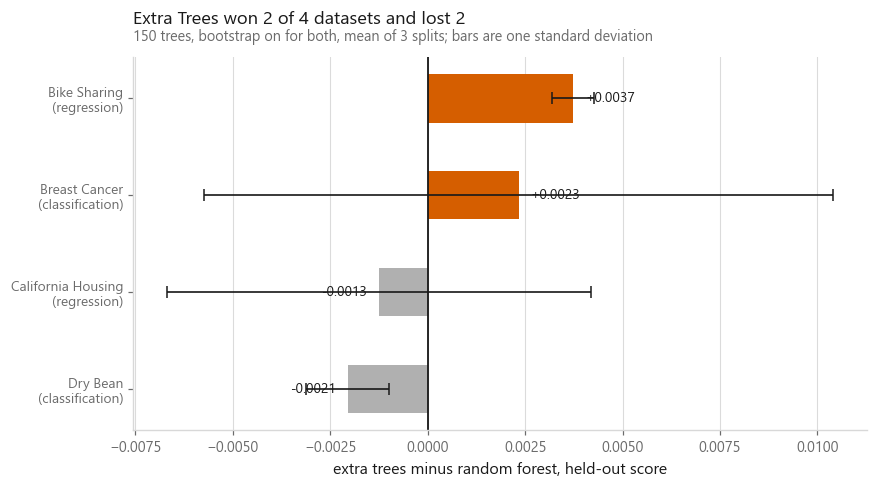

In [15]:
order = gaps["mean"].sort_values().index
positions = np.arange(len(order))
values = gaps.loc[order, "mean"].to_numpy()
errors = gaps.loc[order, "std"].fillna(0).to_numpy()

fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.barh(positions, values, height=0.5,
        color=[style.HIGHLIGHT if v > 0 else style.NEUTRAL for v in values])
ax.errorbar(values, positions, xerr=errors, fmt="none", ecolor=style.INK,
            elinewidth=1.1, capsize=4)
ax.axvline(0, color=style.INK, lw=1.2)
for i, (value, dataset) in enumerate(zip(values, order)):
    ax.annotate(f"{value:+.4f}", xy=(value, i),
                xytext=(8 if value >= 0 else -8, 0), textcoords="offset points",
                ha="left" if value >= 0 else "right", va="center",
                fontsize=9, color=style.INK)
ax.set_yticks(positions, [f"{d}\n({TASKS[d][2]})" for d in order], fontsize=9)
ax.set_xlabel("extra trees minus random forest, held-out score")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
style.title(ax, f"Extra Trees won {wins} of {len(order)} datasets and lost {len(order) - wins}",
            f"150 trees, bootstrap on for both, mean of {SPLITS} splits; "
            "bars are one standard deviation")
style.save(fig, FIG / "fig-05-scoreboard.png")

The sign flips, and that is the finding. Anybody who tells you Extra Trees are
better than random forests, or worse, is describing their dataset rather than the
algorithm. The bars that straddle zero are the ones where the choice does not
matter at all and the timing table should decide it for you.

A rough guide to which side you will land on, consistent with the mechanism in
section 2. Random thresholds are a form of smoothing, so they tend to help where
the true relationship is smooth and the data is noisy, and to hurt where the
signal sits at a sharp threshold that a greedy search would find exactly. That is
a hypothesis about your data, not a rule, and it is cheap to test: both classes
take the same arguments, so swapping one for the other is a one-word change.

The clock is less settled than section 4 made it sound, and the scoreboard's own
fit-seconds column is where that shows. Section 4 timed thirty trees on one
thread and Extra Trees won every dataset. This table times a hundred and fifty
trees across all cores, and on the smallest dataset in the set the ordering
reverses: the printed line names it.

Both numbers are real, and the reason they disagree is the mechanism. Skipping
the sort saves work per split. That saving only turns into wall clock when split
search is what you are paying for, which needs enough rows to make sorting
expensive and enough distinct values per column for the sort to have real work to
do. On a few hundred rows and a couple of dozen columns the split search is
already cheap, so the fit is dominated by costs both families share: allocating
the trees, dispatching across cores, and the per-tree bookkeeping. Shrinking a
component that is not the bottleneck does not shrink the total, and the wider the
dataset and the taller it is, the more of the bill the sort accounts for. The
single-threaded table says the same thing from the other side: its largest
speedup and its smallest sit on the largest and the smallest datasets.

So the useful version of the speed claim is conditional. Extra Trees are faster
where split search dominates, which is most of the cases where you would care
about fit time at all. If you are tuning a model and each fit is a coffee break,
you are in that regime and the difference compounds through every experiment you
run. If each fit is under a second, the choice is not a speed decision and the
ordering can go either way.

## Cheat sheet

| | |
|---|---|
| **What changes** | The split threshold is drawn uniformly at random per candidate feature instead of chosen by an exhaustive scan |
| **What also changes** | `bootstrap` defaults to `False` on Extra Trees and `True` on random forests. Set it explicitly before comparing anything |
| **Speed** | Faster where split search is the dominant cost, because there is no sort. The saving is per split, so it needs enough rows and enough distinct values per column to show up. On the smallest dataset here the scoreboard timing went the other way |
| **Accuracy** | Dataset dependent, and the sign flips. Test both; it costs one word |
| **Tuning** | Same dials as a random forest: `n_estimators`, `max_features`, `min_samples_leaf`. `max_features` matters more here, because it controls how many random offers each node gets to choose from |
| **Trees needed** | Expect to need at least as many as a random forest, since each individual tree is weaker |
| **Feature importance** | Same impurity-based bias as a random forest, and arguably worse, since random thresholds spread importance across correlated columns. Use permutation importance |
| **Next** | [AdaBoost](../04-adaboost/), which builds trees in sequence instead of in parallel and attacks bias rather than variance |

## What to remember

1. The only algorithmic change is that the threshold is a random draw instead of
   the best of an exhaustive scan. Everything else is a random forest.
2. scikit-learn's defaults also differ in `bootstrap`. Compare with it held fixed
   or you are measuring two changes and reporting one.
3. Skipping the sort is where the speed comes from, and it is a saving per split
   rather than a saving per fit. It held on every dataset in the single-threaded
   timing table and reversed on the smallest dataset in the scoreboard's own
   fit-seconds column. Speed is conditional on split search being the dominant
   cost, which needs enough rows and enough distinct values per column.
4. Bias and variance are properties of a procedure, so measuring them means
   resampling the training set many times, not inspecting one fitted model.
5. With one observation of `y` per test point, the measured bias term includes
   the irreducible noise. Say so rather than pretending otherwise.
6. A single extremely randomised tree is worse than a single greedy tree. The
   ensemble has to earn that back through decorrelation, and whether it earns
   back more than it spent is a question about your data.
7. The ranking between the two flips across the house datasets. Try both and let
   the held-out score decide.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [04-04 AdaBoost](../04-adaboost/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#ExtraTrees` `#RandomForest` `#Ensemble` `#BiasVariance`
`#DecisionTrees` `#Python` `#ScikitLearn` `#DataScience` `#MLTutorial`